In [1]:
%load_ext autoreload
%autoreload 2

# Heston Stochastic Volatility Model

This is a basic simulator for a Heston Stochastic Volatility Model, which utilizes the QuantLib library to generate simulations of the HSV model using an efficient C++ implementation.

In [2]:
import numpy as np
import bayesflow as bf
import QuantLib as ql
import matplotlib.pyplot as plt

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
/home/a_huangm13/Documents/Mentoring/BayesTool/bayessmile/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import jax
jax.devices()

[CudaDevice(id=0)]

g## Prior Specifications

To start, we specify the prior distributions that we are going to draw from to generate our HSV paths. We start by defining our parameters globally so they are easy to modify if needs be. The distributions we are drawing from will be specified in the functions we actually use to draw priors. We use transformation functions to center our actual distributions around the values we picked.

### Parameters

**v0 - Initial volatility**<br>
The initial value for our volatility path. Because volatility is modeled as a mean-reverting random process, this defines the starting point of our walk

**$\theta$ - Long-run Mean of Volatility**<br>
The long-run mean value for our volatility. It is the value that our volatility process will tend towards after experiencing shocks.

**$\kappa$ - Volatility Mean Reversion Rate**<br>
The speed at which the volatility process returns to its mean value after experiencing a shock. In the volatility process, it is described as $\kappa * (\theta - v_t)$

**$\sigma$ - Volatility of Volatility**<br>
The variance present in our volatility process. It determines the scale of fluctuations in our volatility process, meaning a higher frequency of more extreme volatility events with an increase in this parameter.

**$\rho$ - Return/Volatility Correlation**<br>
The correlation coefficient between the brownian motions used in the price and volatility processes. In real markets, this value is negative, meaning when prices drop, volatility increases.



In [4]:
SPOT_MEAN = 100
SPOT_STD = 15

VOL_MEAN = 0.04
VOL_STD = 0.002

KAPPA_MEAN = 1.0
KAPPA_STD = 0.25

SIGMA_MEAN = 0.66
SIGMA_STD = 0.15
SIGMA_SCALE = 10 # Linear scaling parameter for model fitting

RHO_ALPHA = 2
RHO_BETA = 5

**Prior Distributions**<br>
To draw from our desired distributions, we define a to_lognormal() transformation such that when we draw from a normal distribution with the transformed mean and std and then log transform the output, our resultant log-normal distribution has the originally specified mean and std. We mostly define our variables as transformations from the normal distribution so are prior draws are all similarly scaled (this excludes our draws for sigma and rho, as these values must be bounded and specified differently).

In [5]:
def to_lognormal(mean, std) :
    sigma = np.sqrt(np.log(1 + std**2 / mean**2))
    mu = np.log(mean**2) - sigma**2 / 2
    return mu, sigma

def to_spot(norm_draw):
    log_mean, log_std = to_lognormal(SPOT_MEAN, SPOT_STD)
    scaled_norm = norm_draw * log_std + log_mean
    return np.exp(scaled_norm)

def to_v0(norm_draw):
    log_mean, log_std = to_lognormal(VOL_MEAN, VOL_STD)
    scaled_norm = norm_draw * (log_std * 2) + log_mean
    return np.exp(scaled_norm)

def to_theta(norm_draw):
    log_mean, log_std = to_lognormal(VOL_MEAN, VOL_STD)
    scaled_norm = norm_draw * log_std + log_mean
    return np.exp(scaled_norm)

def to_kappa(norm_draw):
    log_mean, log_std = to_lognormal(KAPPA_MEAN, KAPPA_STD)
    scaled_norm = norm_draw * log_std + log_mean
    return np.exp(scaled_norm)

def draw_sigma(upper_bound) :
    epsilon = 10 ** (-6)
    return (np.random.beta(6, 6) * (0.9 * upper_bound) + epsilon) * SIGMA_SCALE

def draw_rho() :
    # Here we force this value negative and bound it at -0.9 to avoid over-correlating our processes
    return np.random.beta(RHO_ALPHA, RHO_BETA) * -0.9 - 0.05

def draw_priors():
    #spot = np.random.normal()
    # spot = 100
    v0 = np.random.normal()
    theta = np.random.normal()
    kappa = np.random.normal()
    sigma = draw_sigma(upper_bound=np.sqrt(2*to_kappa(kappa)*to_theta(theta)))
    rho = draw_rho()
    return {#"spot":spot,
            "v0":v0,
            "theta":theta,
            "kappa":kappa,
            "sigma":sigma,
            "rho":rho}

## Defining our Simulator

Next, we define our simulator for the Heston Stochastic Volatility model, using QuantLib as the backend for our model for fast calculation. Using a Bayesflow simulator, we combine our draw_priors() function with our single path simulator to create a simulator object that can be used in our workflow


In [6]:
def single_heston_draw(v0, theta, kappa, sigma, rho, spot=100, steps=500, dt=1/500, maturity=1.0):
    # Transform draws for spot, v0, theta, and kappa into the correct space
    # spot = to_spot(spot)
    v0 = to_v0(v0)
    theta = to_theta(theta)
    kappa = to_kappa(kappa)
    sigma = sigma / SIGMA_SCALE

    spot_quote = ql.SimpleQuote(spot)
    yield_ts = ql.YieldTermStructureHandle(ql.FlatForward(0, ql.UnitedStates(ql.UnitedStates.NYSE), 0.05, ql.Actual365Fixed()))
    div_ts = ql.YieldTermStructureHandle(ql.FlatForward(0, ql.UnitedStates(ql.UnitedStates.NYSE), 0.0, ql.Actual365Fixed()))

    process = ql.HestonProcess(yield_ts, div_ts, ql.QuoteHandle(spot_quote), v0, kappa, theta, sigma, rho, ql.HestonProcess.QuadraticExponentialMartingale)

    # Create a gaussian random sequence
    sequence_generator = ql.UniformRandomSequenceGenerator(2 * steps, ql.UniformRandomGenerator())
    gaussian_sequence_generator = ql.GaussianRandomSequenceGenerator(sequence_generator)

    # Define a path generator for this process
    time_grid = ql.TimeGrid(maturity, steps)
    path_generator = ql.GaussianMultiPathGenerator(
    process,
    time_grid,
    gaussian_sequence_generator,
    False # Brownian bridge flag
    )

    # Generate the price path
    sample = path_generator.next()
    multi_path = sample.value()

    price_path = np.array([multi_path[0][i] for i in range(steps + 1)])

    # Calculate and return log prices
    #log_returns = np.log(price_path[1:] / price_path[:-1])

    return dict(price_path=price_path)

simulator = bf.make_simulator([draw_priors, single_heston_draw])

## Prior Checking

In order to confirm the validity of our results, we conduct analysis on the priors we draw to confirm that they look as expected (this will include prior pushforward checks once I can implement these).

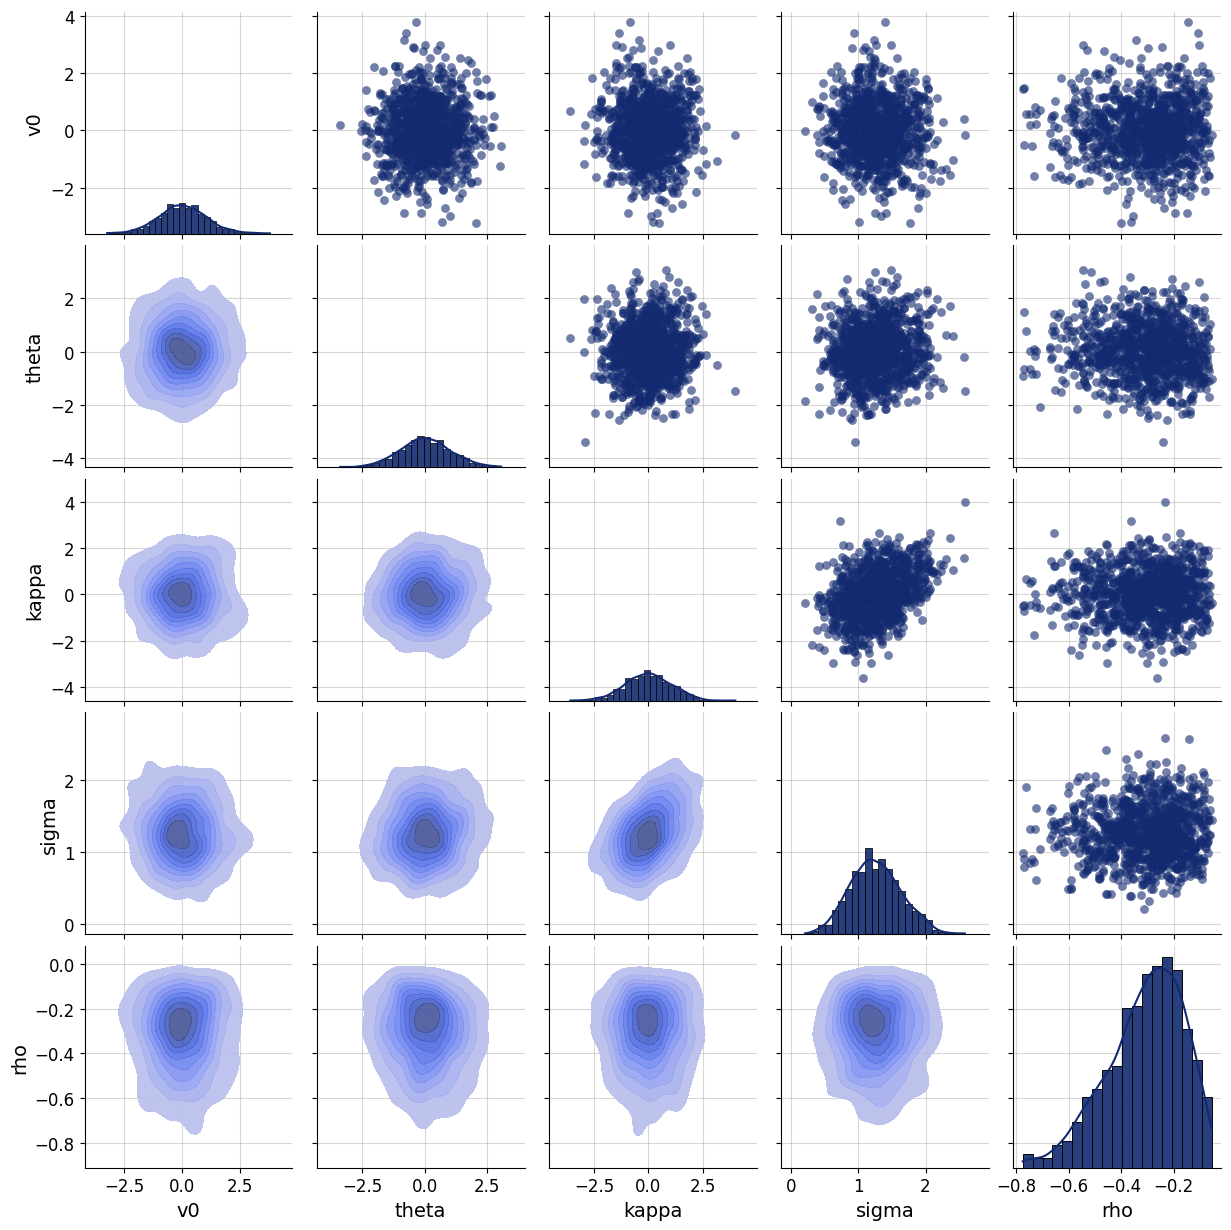

In [7]:
prior_samples = simulator.simulators[0].sample(1000)

grid = bf.diagnostics.plots.pairs_samples(
    prior_samples, variable_keys=["v0", "theta", "kappa", "sigma", "rho"]
)

In [8]:
posterior_samples = simulator.sample(1000)

In [9]:
posterior_samples["price_path"].shape

(1000, 501)

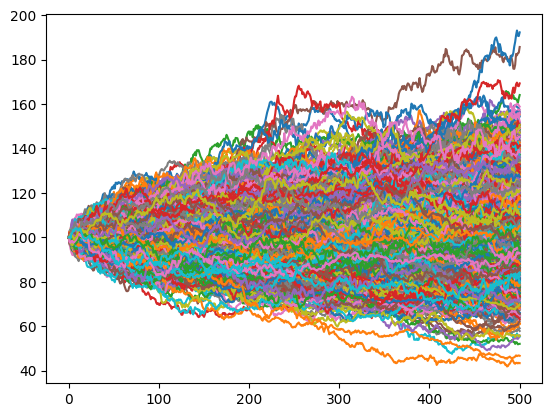

In [10]:
paths = posterior_samples['price_path']
price_paths = []


for path in paths:
    plt.plot(path)

## Setting Up Our Workflow

In order to create a fully functioning SBI workflow, we create our Bayesflow workflow object, which involves creating a few different helper objects.

**Adapter**<br>
To start, we create our adapter, which we use to make the data from our simulation palatable to our inference and summary networks.

In [11]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series("price_path")
    .standardize(include="rho", mean=-0.307, std=0.1435)
    .concatenate(["v0", "theta", "kappa", "sigma", "rho"], into="inference_variables")
    .rename("price_path", "summary_variables")
)

In [12]:
adapted_sims = adapter(simulator.sample(100))

In [13]:
for k, v in adapted_sims.items():
    print(k, v.shape)

inference_variables (100, 5)
summary_variables (100, 501, 1)


**Creating The Workflow**<br>
Then, we combine all the pieces we have created so far to create our overall workflow, which will combine our simulator, adapter, and summary network with an inference network.

In [14]:
summary_net = bf.networks.TimeSeriesNetwork(dropout=0.1)

inference_net = bf.networks.FlowMatching(dropout=0.1)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    checkpoint_filepath="checkpoints/hsv_workflow",
    checkpoint_name="hsv_tsn_dm"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


## Training Our Model
Now, we finally get to train our model. We use the workflow we have already created to generate a number of simulations with unique prior draws, which will then train the network to recognize the different parameters we have from the paths we generate, or find in the real world!

In [15]:
# train = workflow.simulate(10000)
validation = workflow.simulate(300)

In [16]:
history = workflow.fit_online(
    epochs=500,
    num_batches_per_epoch=100,
    batch_size=32,
    validation_data=validation
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/500


E0327 15:04:37.531958    6959 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.27 = f32[32,32]{1,0} fusion(concatenate.6, get-tuple-element.522, get-tuple-element.521), kind=kCustom, calls=gemm_fusion_dot_general.27_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["64","16"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0327 15:04:37.532019    6959 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.27_computation.clone {
  parameter_0.11 = f32[32,384]{1,0} parameter(0)
  parameter_1.11 = f32[32,384]{1,0} parameter(1)
  dot_general.47 = f32[32,32]{1,0} dot(parameter_0.11, parameter_1.11), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 2.3509

E0327 15:04:51.968865    6952 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 2.3509 - val_loss: 2.0035
Epoch 2/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 2.0074 - val_loss: 1.8624
Epoch 3/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 1.9270 - val_loss: 1.7502
Epoch 4/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 1.8210 - val_loss: 1.9090
Epoch 5/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 1.7761 - val_loss: 1.7440
Epoch 6/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 1.7673 - val_loss: 1.7392
Epoch 7/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 1.7068 - val_loss: 1.6417
Epoch 8/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 1.6967 - val_loss: 1.6872
Epoch 9/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 1.6739 - val_loss: 1.6536
Epoch 10/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 1.7071 - val_loss: 1.6994
Epoch 11/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 1.6781 - val_loss: 1.6281
Epoch 12/500
100/100 ━━━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 1.04 hours.
INFO:bayesflow:Training is now finished.
            You can find the trained approximator at 'checkpoints/hsv_workflow/hsv_tsn_dm.hsv_tsn_dm.keras'.
            To load it, use approximator = keras.saving.load_model(...).


## Diagnostics

Finally, we get to see how well our model actually performs! We can do this through a number of different methods.

**Plotting Loss**<br>
To start, we will plot the loss of our inference network. This is not a very effective check for how well our network has actually learned to approximate our posterior distributions, but it does serve as a good negative check -- if this doesn't converge, we need to check our work.

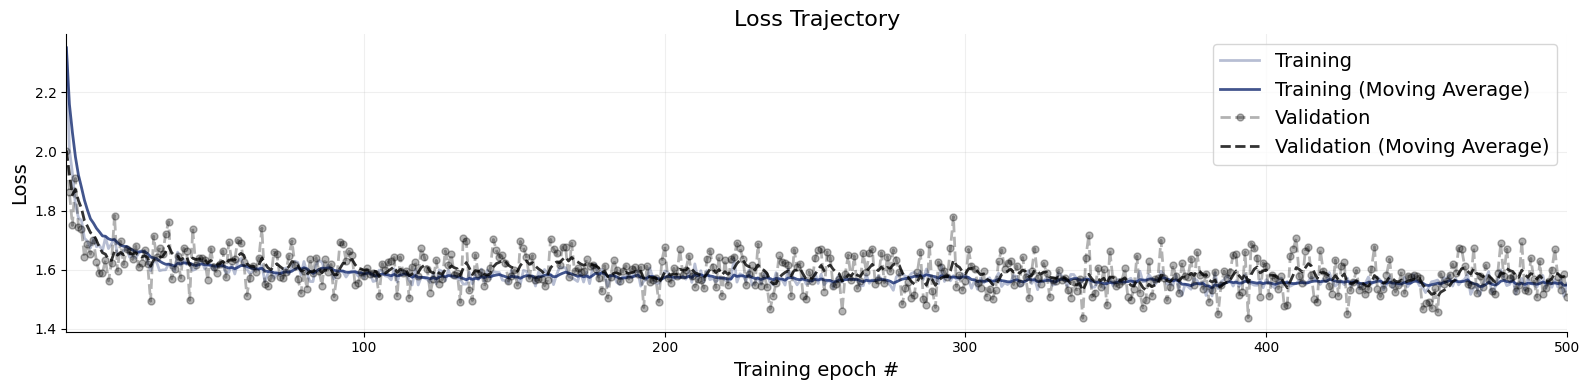

In [18]:
f = bf.diagnostics.plots.loss(history)

**Checking Recoveries**<br>
We can also check the recoveries of the free parameters in our model, which allows us to understand exactly how well our model has learned our parameters. If we see a lack of correlation here, or a non-linear shape, this indicated issues with our learning, though these may not always be solvable.

Running simulations
Sampling


E0328 15:51:54.528187    6971 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[300,384]{1,0} fusion(get-tuple-element.8, get-tuple-element.13), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0328 15:51:54.528309    6971 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0.1 = f32[300,128]{1,0} parameter(0)
  parameter_1.1 = f32[128,384]{1,0} parameter(1)
  ROOT dot_general.5 = f32[300,384]{1,0} dot(parameter_0.1, parameter_1.1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E03

Making plots


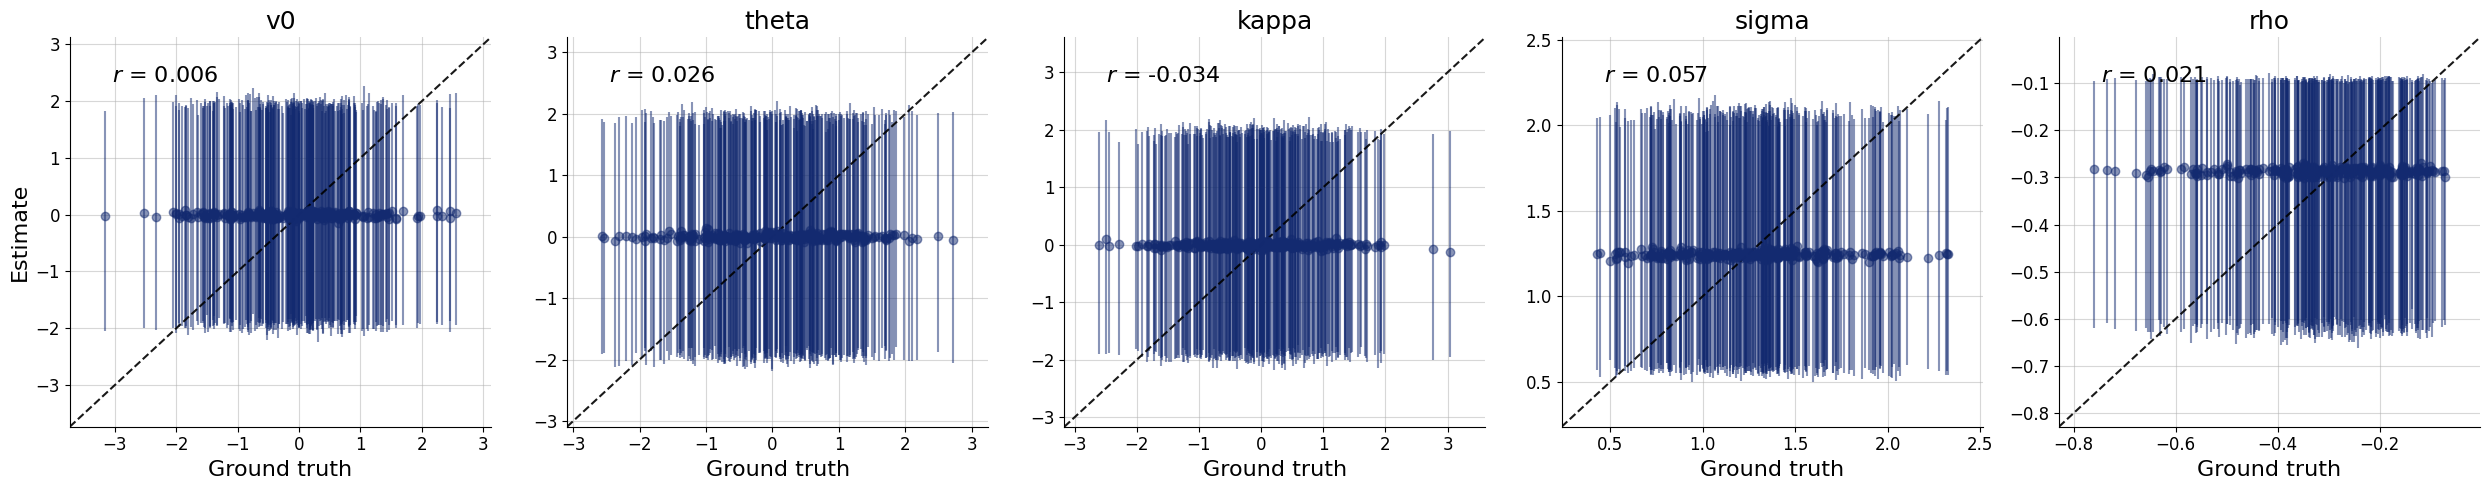

In [19]:
num_datasets = 300
num_samples = 1000

# Simulate 300 scenarios
print("Running simulations")
test_sims = workflow.simulate(num_datasets)

# Obtain num_samples posterior samples per scenario
print("Sampling")
samples = workflow.sample(conditions=test_sims, num_samples=num_samples)

print("Making plots")
f = bf.diagnostics.plots.recovery(samples, test_sims)

plt.savefig("HSV_recoveries.png")

**Posterior Sampling**<br>
Our second-best test for the quality of our model is to look at the actual posterior distributions we get from our model. If we get reasonable and tight posterior distributions, this suggests that our network is fairly confident about the values of the parameters we are trying to estimate. As such, this check can help us figure out how well our model is calibrated.

In [ ]:
labels = ["v0", "theta", "kappa", "sigma", "rho"]

truths = np.asarray([test_sims[labels[x]][0].item() for x in range(len(labels))])

out_samples = np.asarray([samples[labels[x]][0].flatten() for x in range(len(labels))]).T

d = out_samples.shape[1]
fig, axes = plt.subplots(d, d, figsize=(8, 8))

for i in range(d):
    for j in range(d):
        ax = axes[i, j]
        if i == j:
            ax.set_facecolor("white")  # set background blue
            ax.hist(out_samples[:, i], bins=40, histtype="step", color="lightblue")
            ax.axvline(truths[i], color="red")
            ax.set_xlabel(labels[i])
        elif i < j:
            ax.set_facecolor("midnightblue")  # set background blue
            h = ax.hist2d(out_samples[:, j], out_samples[:, i],
                          bins=50, cmap="viridis")
            ax.plot(truths[j], truths[i], "o", color="red")
        else:
            ax.axis("off")

plt.tight_layout()

plt.plot()